# Dispute Reason Classification & Support-Ticket Routing — QLoRA on 8 GB

**Goal.** Fine-tune a small instruction model so it reads a customer's banking
complaint and routes it to the correct **support queue** — the first decision in
any real triage system.

## Problem statement
A digital bank receives free-text complaints ("*I was charged twice*", "*the ATM
ate my card*"). A human or model must send each ticket to the **team that can
resolve it**. We frame this as **8-way single-label classification** over
operational routing queues, and care about routing-specific quality:

- **Accuracy / macro-F1** — overall and per-queue correctness (macro-F1 keeps
  rare queues honest).
- **Top-3 accuracy** — in a real UI the agent sees a short ranked list; if the
  right queue is in the top 3, routing is still *useful*.
- **Calibrated confidence** — a router that says "90%" should be right ~90% of
  the time, so low-confidence tickets can be escalated to a human.
- **Where it misroutes** — which queues bleed into each other, and why.

## Approach in one line
Take **Qwen2.5-1.5B-Instruct**, fine-tune a **QLoRA** adapter (4-bit base +
small trainable low-rank matrices) on an instruction-style `complaint → queue`
dataset built by remapping **Banking77**'s 77 intents into **8 routing queues**,
and compare it head-to-head against the **zero-shot base model**.

## 1 · Why LoRA / QLoRA, and the memory trade-offs

Full fine-tuning of even a 1.5B model updates **all 1.5B parameters** and stores
optimizer state (Adam keeps 2 extra tensors per weight). In fp16/bf16 that is
roughly:

| Item | Full FT (1.5B) | QLoRA (this notebook) |
|---|---|---|
| Base weights | ~3.0 GB (bf16) | **~1.0 GB (4-bit NF4)** |
| Trainable params | 1.5B | **~18M (LoRA, ~1.2%)** |
| Adam optimizer state | ~12 GB | **~0.15 GB** (only on LoRA params) |
| Gradients | ~3 GB | ~0.04 GB |
| **Feasible on 8 GB?** | ❌ no | ✅ **yes (~5 GB peak)** |

**LoRA** freezes the pretrained weights *W* and learns a low-rank update
`ΔW = B·A` (rank *r* ≪ dimension). Only *A* and *B* train, so gradients +
optimizer state shrink by ~100×.

**QLoRA** adds one more trick: store the *frozen* base weights in **4-bit NF4**
(quantized), dequantizing on-the-fly for each matmul. The LoRA adapters stay in
bf16. This is what lets a 1.5B model **train** — not just run — on an 8 GB
laptop GPU.

> **The cost:** 4-bit quantization is lossy, so the *base* (zero-shot) model is
> slightly degraded vs full precision, and very large *r* gives diminishing
> returns. We measure the net effect rather than assume it.

In [1]:
# Memory hygiene for an 8 GB card: reduce allocator fragmentation. MUST be set
# before CUDA initialises, so this is the very first thing we do.
import os
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed,
)
from peft import LoraConfig
from trl import SFTTrainer, SFTConfig

# Project helpers (importable, unit-checked) — keeps notebook DRY.
from routing_taxonomy import ROUTES, ROUTE_DESCRIPTIONS, ID2ROUTE, ROUTE2ID
from routing_pipeline import (
    CONFIG, load_routing_dataset, build_messages, SYSTEM_PROMPT,
    to_sft_dataset, RouteScorer, routing_metrics,
)
from inference import expected_calibration_error

set_seed(CONFIG.seed)
sns.set_theme(style="whitegrid")
CONFIG.figures_dir.mkdir(parents=True, exist_ok=True)

assert torch.cuda.is_available(), "CUDA GPU required."
print("GPU         :", torch.cuda.get_device_name(0))
print("Total VRAM  :", round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), "GB")
print("torch / cuda:", torch.__version__)
print("Model       :", CONFIG.model_id)
print("Routes (8)  :", ROUTES)

GPU         : NVIDIA GeForce RTX 4060 Laptop GPU
Total VRAM  : 8.2 GB
torch / cuda: 2.12.0+cu130
Model       : Qwen/Qwen2.5-1.5B-Instruct
Routes (8)  : ['Card Disputes & Fraud', 'Payments & Transfers', 'Card Operations', 'ATM & Cash', 'Account Access & Security', 'Top-Up & Funding', 'Identity & Verification', 'Fees, Rates & Product Info']


## 2 · Dataset — Banking77 remapped into 8 routing queues

[Banking77](https://huggingface.co/datasets/PolyAI/banking77) is 13k customer
queries labelled with **77 fine intents**. A router doesn't need 77 destinations
— it needs the right **team**. We collapse the 77 intents into **8 operational
queues** with an explicit, auditable map in `routing_taxonomy.py`
(`assert_full_coverage` fails loudly if a future Banking77 revision drifts — it
already caught the oddly-named `reverted_card_payment?` label).

Splits are **stratified by queue** so rare queues stay represented.

In [2]:
ds = load_routing_dataset(CONFIG)
print({k: len(v) for k, v in ds.items()})
pd.DataFrame(ds["train"][:5])[["text", "route"]]

Using the latest cached version of the dataset since PolyAI/banking77 couldn't be found on the Hugging Face Hub


Found the latest cached dataset configuration 'default' at /home/ahmad/.cache/huggingface/datasets/PolyAI___banking77/default/0.0.0/689fcc406cf47a5fbe15f09393be5f206a009fcc (last modified on Wed Jun 10 02:53:20 2026).


{'train': 4918, 'validation': 800, 'test': 1200}


,text,route
0,I did not receive the correct amount of cash.,ATM & Cash
1,I believe my card has been compromised because...,Card Disputes & Fraud
2,You provide support in what countries?,"Fees, Rates & Product Info"
3,I purchased something and the seller hasn't re...,Card Disputes & Fraud
4,"To deliver to the US, how long will it take?",Card Operations


### Label distribution & input length
Banking77 is fairly balanced at the intent level, but our **remap** makes some
queues bigger than others (e.g. *Card Operations* absorbs 16 intents). Macro-F1
and stratified sampling matter precisely because of this skew.

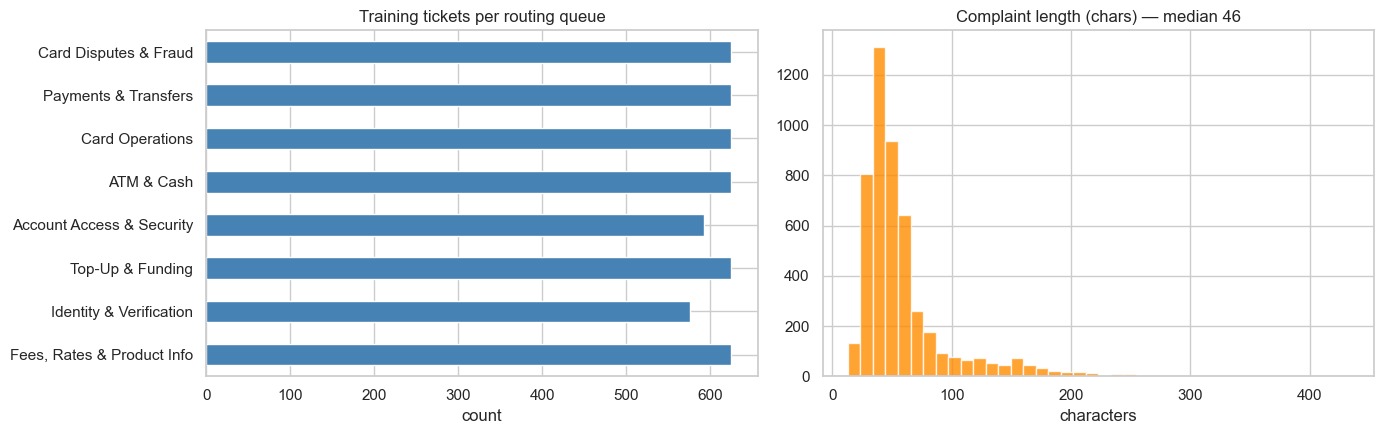

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) routing-queue distribution on the train split
counts = pd.Series(ds["train"]["route"]).value_counts().reindex(ROUTES)
counts.plot.barh(ax=ax[0], color="steelblue")
ax[0].set_title("Training tickets per routing queue")
ax[0].set_xlabel("count"); ax[0].invert_yaxis()

# (b) complaint length in characters
lengths = pd.Series([len(t) for t in ds["train"]["text"]])
ax[1].hist(lengths, bins=40, color="darkorange", alpha=0.8)
ax[1].set_title(f"Complaint length (chars) — median {int(lengths.median())}")
ax[1].set_xlabel("characters")

plt.tight_layout()
plt.savefig(CONFIG.figures_dir / "label_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

In [4]:
# How the 77 intents fold into 8 queues (sanity view of the taxonomy).
from collections import Counter
from routing_taxonomy import INTENT_TO_ROUTE
c = Counter(INTENT_TO_ROUTE.values())
for r in ROUTES:
    print(f"{c[r]:2d} intents  →  {r}")

10 intents  →  Card Disputes & Fraud
11 intents  →  Payments & Transfers
16 intents  →  Card Operations
 7 intents  →  ATM & Cash
 6 intents  →  Account Access & Security
10 intents  →  Top-Up & Funding
 6 intents  →  Identity & Verification
11 intents  →  Fees, Rates & Product Info


## 3 · Instruction-style dataset & the routing prompt

We turn each row into an **instruction**: a system message that lists the 8
queues + one-line definitions (the *rubric*), and a user message containing the
complaint. The target completion is the **bare queue name**.

The same prompt is used for the zero-shot baseline and for fine-tuning, so the
comparison is apples-to-apples. (The rubric is ~265 tokens, which is exactly why
`CONFIG.max_length = 384` — short enough to be cheap, long enough that the
completion is never truncated away.)

In [5]:
print("SYSTEM PROMPT (the routing rubric the model sees)\n" + "="*70)
print(SYSTEM_PROMPT)

# Tokenizer first — we need it to render the chat prompt.
tok = AutoTokenizer.from_pretrained(CONFIG.model_id)
if tok.pad_token is None:
    tok.pad_token = tok.eos_token

example = ds["train"][0]
rendered = tok.apply_chat_template(build_messages(example["text"]),
                                   tokenize=False, add_generation_prompt=True)
print("\nRENDERED PROMPT (tail)\n" + "="*70)
print("..." + rendered[-300:])
print("TARGET COMPLETION:", repr(example["route"]))

SYSTEM PROMPT (the routing rubric the model sees)
You are a customer-support ticket router for a digital bank. Read the customer's message and assign it to exactly ONE routing queue from the list below. Reply with the queue name only — no explanation.

Routing queues:
- Card Disputes & Fraud: Unrecognised / duplicate / reverted charges, refunds, compromised or lost/stolen cards.
- Payments & Transfers: Bank transfers and direct debits: timing, fees, failed/declined/pending transfers, beneficiaries, incoming money.
- Card Operations: Ordering, delivery, activation, linking and physical malfunction of physical/virtual cards (contactless, expiry, declined card use).
- ATM & Cash: Cash withdrawals and ATMs: charges, declines, wrong amount dispensed, swallowed cards, withdrawal exchange rates.
- Account Access & Security: PIN/passcode, personal-detail edits, lost phone, account closure.
- Top-Up & Funding: Adding money to the account by card/bank/cash/cheque: fees, limits, failures, reversa


RENDERED PROMPT (tail)
...eligibility.
- Fees, Rates & Product Info: General product questions: exchange rates/charges, supported cards & currencies, country support, card acceptance, digital wallets.<|im_end|>
<|im_start|>user
Customer message: "I did not receive the correct amount of cash."<|im_end|>
<|im_start|>assistant

TARGET COMPLETION: 'ATM & Cash'


### How we read a *label* out of a generative model — constrained scoring
A chat model normally *generates* free text. For a router with a fixed set of
destinations that is wasteful and unsafe (it might invent a queue). Instead, for
each input we **score all 8 queue names as candidate completions** and take the
length-normalised log-likelihood, then softmax across the 8 → a real probability
per queue. This:

- guarantees a **valid** label,
- yields **top-3** rankings and a **confidence** for free,
- works **identically** for the base and fine-tuned models.

`RouteScorer` (in `routing_pipeline.py`) implements this with a memory-frugal
`logit − logsumexp` trick so the 152k-token vocabulary doesn't blow up 8 GB.

## 4 · Baseline — zero-shot Qwen2.5-1.5B (4-bit)

Before any training, how well does the **instruct base model** route, just from
the rubric? This is the bar QLoRA must beat.

In [6]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",                 # NormalFloat4: better for weights than int4
    bnb_4bit_compute_dtype=torch.bfloat16,     # matmuls run in bf16
    bnb_4bit_use_double_quant=True,            # quantize the quant-constants too (~0.4 GB saved)
)

base_model = AutoModelForCausalLM.from_pretrained(
    CONFIG.model_id, quantization_config=bnb_config, device_map="cuda",
)
base_model.eval()
print("Base model loaded in 4-bit. VRAM allocated:",
      round(torch.cuda.memory_allocated()/1e9, 2), "GB")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

/home/ahmad/AI/Projects/lora-dispute-ticket-routing/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Base model loaded in 4-bit. VRAM allocated: 1.14 GB


In [7]:
test_texts  = list(ds["test"]["text"])
test_labels = np.array(ds["test"]["label"])

base_scorer = RouteScorer(base_model, tok, CONFIG)
print(f"Scoring {len(test_texts)} test tickets x {len(ROUTES)} queues (zero-shot)...")
probs_base = base_scorer.score_texts(test_texts)

metrics_base = routing_metrics(probs_base, test_labels)
metrics_base["ece"] = expected_calibration_error(probs_base, test_labels)
print("ZERO-SHOT BASELINE:", {k: round(v, 4) for k, v in metrics_base.items()})

Scoring 1200 test tickets x 8 queues (zero-shot)...


ZERO-SHOT BASELINE: {'accuracy': 0.6792, 'macro_f1': 0.6819, 'top3_accuracy': 0.8733, 'ece': 0.184}


## 5 · QLoRA fine-tuning setup (8 GB-friendly)

Key choices and *why* they fit 8 GB:

| Knob | Value | Why |
|---|---|---|
| 4-bit NF4 base | `load_in_4bit` | base weights ~1 GB instead of ~3 GB |
| LoRA rank `r` | 16 (α=32) | ~18M trainable params (~1.2%); α=2·r is a safe default |
| target modules | all attn + MLP proj | adapting MLP too helps classification |
| batch / grad-accum | **4 × 4 = 16** | micro-batch 4 keeps the 152k-vocab loss tensor in budget; accumulation recovers a stable effective batch |
| `paged_adamw_8bit` | — | 8-bit optimizer + paging avoids OOM spikes |
| gradient checkpointing | on | trades compute for memory (recompute activations) |
| epochs | 2 | small adapter on a clean task converges fast; more risks overfitting |

In [8]:
lora_config = LoraConfig(
    task_type="CAUSAL_LM",
    r=CONFIG.lora_r,
    lora_alpha=CONFIG.lora_alpha,
    lora_dropout=CONFIG.lora_dropout,
    target_modules=list(CONFIG.lora_target_modules),
)

sft_args = SFTConfig(
    output_dir=str(CONFIG.adapter_dir.parent / "_trainer"),
    num_train_epochs=CONFIG.epochs,
    per_device_train_batch_size=CONFIG.per_device_batch_size,
    gradient_accumulation_steps=CONFIG.grad_accum,
    learning_rate=CONFIG.learning_rate,
    warmup_ratio=CONFIG.warmup_ratio,
    lr_scheduler_type="cosine",
    max_length=CONFIG.max_length,
    completion_only_loss=True,        # loss ONLY on the queue name, not the rubric
    packing=False,
    bf16=True,
    optim="paged_adamw_8bit",
    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    logging_steps=20,
    save_strategy="no",
    report_to="none",
)

sft_train = to_sft_dataset(ds["train"], tok)
sft_val   = to_sft_dataset(ds["validation"], tok)
print("SFT example:", {k: (v[:60] + '…' if k == 'prompt' else v)
                        for k, v in sft_train[0].items()})

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


SFT example: {'prompt': '<|im_start|>system\nYou are a customer-support ticket router …', 'completion': 'ATM & Cash'}


### Train
`SFTTrainer` attaches the LoRA adapter to the 4-bit base model (the base stays
frozen) and trains only the adapter. Watch the **loss fall** and
**mean_token_accuracy rise** — on this short-completion task it climbs to ~0.95+
quickly.

In [9]:
base_model.config.use_cache = False  # required with gradient checkpointing

trainer = SFTTrainer(
    model=base_model,
    args=sft_args,
    train_dataset=sft_train,
    eval_dataset=sft_val,
    processing_class=tok,
    peft_config=lora_config,
)
trainer.model.print_trainable_parameters()

train_result = trainer.train()
print("\nFinal train loss:", round(train_result.training_loss, 4))
print("Peak VRAM during training:", round(torch.cuda.max_memory_allocated()/1e9, 2), "GB")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


Step,Training Loss
20,0.232881
40,0.173138
60,0.104042
80,0.117938
100,0.093590
120,0.067890
140,0.066200
160,0.072701
180,0.063605
200,0.061222



Final train loss: 0.0507
Peak VRAM during training: 5.11 GB


In [10]:
# Persist just the adapter (a few tens of MB) — the base model is unchanged.
trainer.model.save_pretrained(str(CONFIG.adapter_dir))
tok.save_pretrained(str(CONFIG.adapter_dir))
print("Adapter saved to", CONFIG.adapter_dir)
import os
sz = sum(os.path.getsize(os.path.join(dp, f))
         for dp, _, fs in os.walk(CONFIG.adapter_dir) for f in fs)
print("Adapter size on disk:", round(sz/1e6, 1), "MB  (vs ~3 GB for the full model)")

Adapter saved to /home/ahmad/AI/Projects/lora-dispute-ticket-routing/outputs/qlora-routing-adapter
Adapter size on disk: 48.4 MB  (vs ~3 GB for the full model)


## 6 · Evaluation — fine-tuned vs zero-shot

`trainer.model` is now the 4-bit base **with the trained LoRA adapter active**.
We score the *same* test set the *same* way, so any difference is the adapter.

In [11]:
# Free the optimizer/scheduler state before eval — on 8 GB the resident Adam
# state (held by `trainer`) otherwise leaves too little room for scoring and OOMs.
import gc
ft_model = trainer.model.eval()
del trainer
gc.collect(); torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

ft_scorer = RouteScorer(ft_model, tok, CONFIG)
print(f"Scoring {len(test_texts)} test tickets (fine-tuned)...")
probs_ft = ft_scorer.score_texts(test_texts)

metrics_ft = routing_metrics(probs_ft, test_labels)
metrics_ft["ece"] = expected_calibration_error(probs_ft, test_labels)
print("FINE-TUNED:", {k: round(v, 4) for k, v in metrics_ft.items()})

Scoring 1200 test tickets (fine-tuned)...


FINE-TUNED: {'accuracy': 0.9567, 'macro_f1': 0.9567, 'top3_accuracy': 0.9933, 'ece': 0.384}


### Before vs after

,accuracy,macro_f1,top3_accuracy,ECE (cal. error)
model,,,,
Zero-shot base,0.679,0.682,0.873,0.184
QLoRA fine-tuned,0.957,0.957,0.993,0.384



Improvement (Δ):
accuracy            0.277
macro_f1            0.275
top3_accuracy       0.120
ECE (cal. error)    0.200


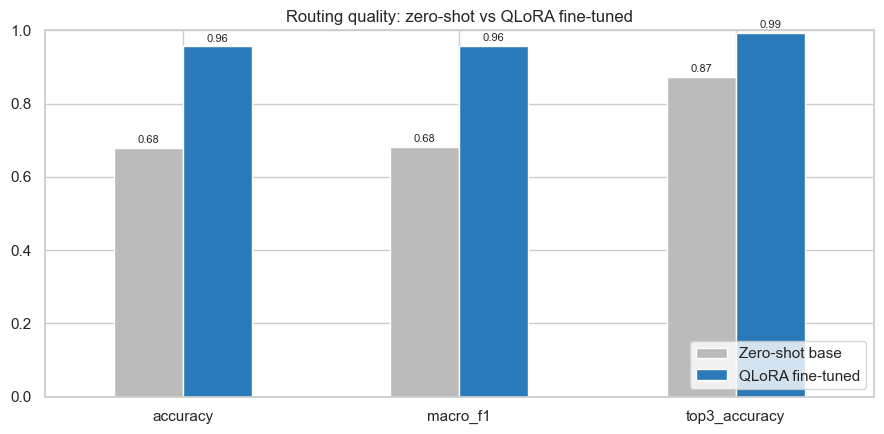

In [12]:
rows = []
for name, m in [("Zero-shot base", metrics_base), ("QLoRA fine-tuned", metrics_ft)]:
    rows.append({"model": name,
                 "accuracy": m["accuracy"],
                 "macro_f1": m["macro_f1"],
                 "top3_accuracy": m["top3_accuracy"],
                 "ECE (cal. error)": m["ece"]})
compare = pd.DataFrame(rows).set_index("model")
delta = (compare.loc["QLoRA fine-tuned"] - compare.loc["Zero-shot base"]).rename("Δ")
display(compare.style.format("{:.3f}"))
print("\nImprovement (Δ):")
print(delta.round(3).to_string())

# bar chart
ax = compare[["accuracy", "macro_f1", "top3_accuracy"]].T.plot.bar(
    figsize=(9, 4.5), rot=0, color=["#bbbbbb", "#2a7ab9"])
ax.set_title("Routing quality: zero-shot vs QLoRA fine-tuned")
ax.set_ylim(0, 1.0); ax.legend(loc="lower right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.2f", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(CONFIG.figures_dir / "base_vs_finetuned.png", dpi=120, bbox_inches="tight")
plt.show()

## 7 · Where does it (mis)route?

A confusion matrix over 8 queues is readable. We look at the fine-tuned model and
then extract the **most common misrouting pairs** — the operational failure mode
(a ticket bounced to the wrong team).

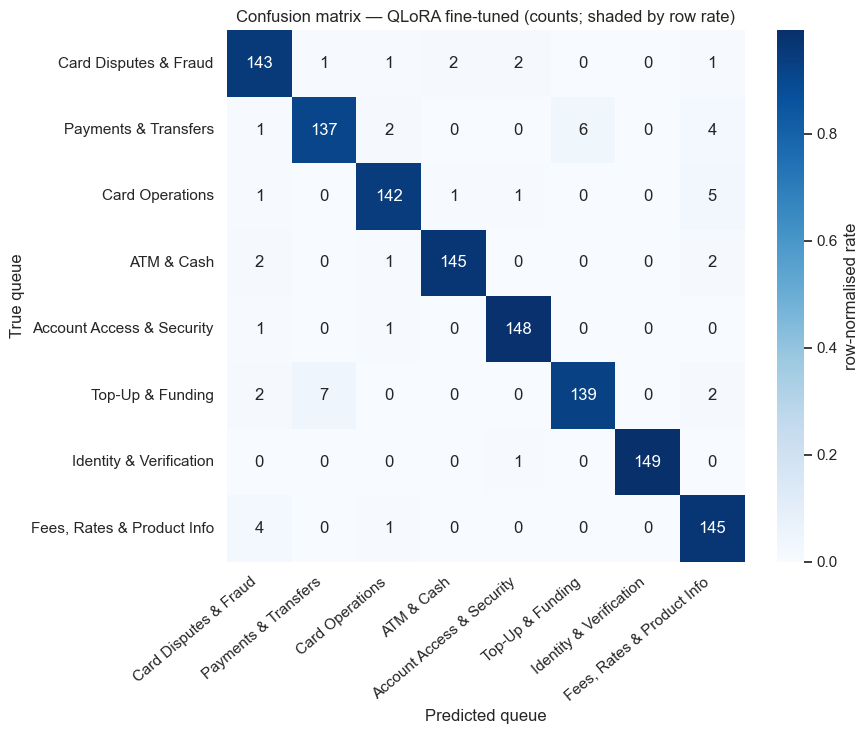

                            precision    recall  f1-score   support

     Card Disputes & Fraud      0.929     0.953     0.941       150
      Payments & Transfers      0.945     0.913     0.929       150
           Card Operations      0.959     0.947     0.953       150
                ATM & Cash      0.980     0.967     0.973       150
 Account Access & Security      0.974     0.987     0.980       150
          Top-Up & Funding      0.959     0.927     0.942       150
   Identity & Verification      1.000     0.993     0.997       150
Fees, Rates & Product Info      0.912     0.967     0.939       150

                  accuracy                          0.957      1200
                 macro avg      0.957     0.957     0.957      1200
              weighted avg      0.957     0.957     0.957      1200



In [13]:
from sklearn.metrics import confusion_matrix, classification_report

pred_ft = probs_ft.argmax(axis=1)
cm = confusion_matrix(test_labels, pred_ft, labels=range(len(ROUTES)))
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

plt.figure(figsize=(9, 7.5))
sns.heatmap(cm_norm, annot=cm, fmt="d", cmap="Blues",
            xticklabels=ROUTES, yticklabels=ROUTES, cbar_kws={"label": "row-normalised rate"})
plt.xlabel("Predicted queue"); plt.ylabel("True queue")
plt.title("Confusion matrix — QLoRA fine-tuned (counts; shaded by row rate)")
plt.xticks(rotation=40, ha="right"); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(CONFIG.figures_dir / "confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

print(classification_report(test_labels, pred_ft, target_names=ROUTES, digits=3, zero_division=0))

In [14]:
# Top misrouting pairs (true ≠ predicted), most frequent first.
mis = []
for i in range(len(ROUTES)):
    for j in range(len(ROUTES)):
        if i != j and cm[i, j] > 0:
            mis.append((cm[i, j], ROUTES[i], ROUTES[j]))
mis.sort(reverse=True)
print("Most common misroutes (count | TRUE → PREDICTED):")
for n, t, p in mis[:8]:
    print(f"  {n:3d} | {t}  →  {p}")

Most common misroutes (count | TRUE → PREDICTED):
    7 | Top-Up & Funding  →  Payments & Transfers
    6 | Payments & Transfers  →  Top-Up & Funding
    5 | Card Operations  →  Fees, Rates & Product Info
    4 | Payments & Transfers  →  Fees, Rates & Product Info
    4 | Fees, Rates & Product Info  →  Card Disputes & Fraud
    2 | Top-Up & Funding  →  Fees, Rates & Product Info
    2 | Top-Up & Funding  →  Card Disputes & Fraud
    2 | Payments & Transfers  →  Card Operations


**Reading the errors.** Confusions cluster where queues are *semantically
adjacent* — e.g. a declined card payment (*Card Operations*) reads a lot like a
declined transfer (*Payments & Transfers*), and an unexpected fee (*Fees/Rates*)
overlaps with a duplicate charge (*Card Disputes*). These are exactly the cases
where **top-3** rescues routing usefulness, and where a confidence threshold
should defer to a human.

## 8 · Qualitative examples — prediction + confidence + top-3

In [15]:
def show(idx):
    p = probs_ft[idx]
    order = np.argsort(-p)[:3]
    true = ID2ROUTE[int(test_labels[idx])]
    pred = ID2ROUTE[int(order[0])]
    flag = "✅" if pred == true else "❌"
    print(f"{flag}  \"{test_texts[idx][:90]}\"")
    print(f"     true: {true}")
    print("     top-3: " + " | ".join(f"{ID2ROUTE[int(i)]} {p[i]:.0%}" for i in order))
    print()

# a few correct + a few wrong
correct_idx = np.where(probs_ft.argmax(1) == test_labels)[0][:3]
wrong_idx   = np.where(probs_ft.argmax(1) != test_labels)[0][:4]
print("— CORRECT —");  [show(i) for i in correct_idx]
print("— MISROUTED —"); [show(i) for i in wrong_idx]

— CORRECT —
✅  "Which credit or debit cards can I use to top up?"
     true: Fees, Rates & Product Info
     top-3: Fees, Rates & Product Info 66% | Top-Up & Funding 11% | ATM & Cash 6%

✅  "Is there a verification code for top-ups?"
     true: Identity & Verification
     top-3: Identity & Verification 54% | Fees, Rates & Product Info 15% | Top-Up & Funding 9%

✅  "Why do you charge fees on card payments?"
     true: Fees, Rates & Product Info
     top-3: Fees, Rates & Product Info 53% | Card Disputes & Fraud 18% | Top-Up & Funding 9%

— MISROUTED —
❌  "Can you tell me the total cost of a transfer?"
     true: Top-Up & Funding
     top-3: Payments & Transfers 30% | Top-Up & Funding 29% | Fees, Rates & Product Info 20%

❌  "How can I fix my card, it got declined twice."
     true: Payments & Transfers
     top-3: Card Operations 36% | Card Disputes & Fraud 18% | Fees, Rates & Product Info 14%

❌  "Do charge fees for transfers?"
     true: Payments & Transfers
     top-3: Top-Up & Fundi

[None, None, None, None]

## 9 · Calibration — is the confidence trustworthy?

For routing, a confidence number is only useful if it's **honest**: among tickets
the model calls "80% sure", ~80% should actually be correct. We bin predictions
by confidence and plot accuracy vs confidence (the **reliability diagram**) and
report **Expected Calibration Error (ECE)**. Points below the diagonal =
*over-confident*.

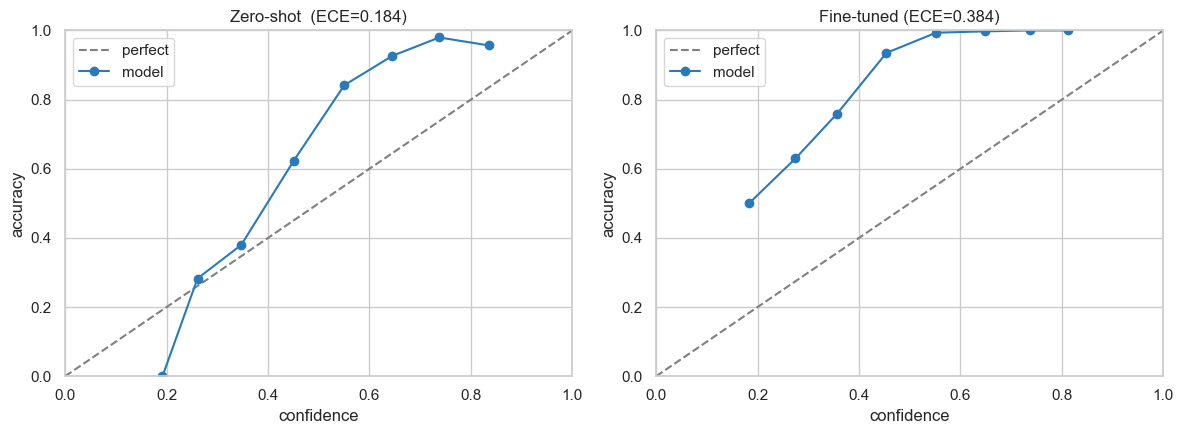

confidence ≥ 0.5:  auto-route 72.2% of tickets  at  99.7% accuracy
confidence ≥ 0.7:  auto-route 16.7% of tickets  at  100.0% accuracy
confidence ≥ 0.9:  auto-route  0.0% of tickets  at  nan% accuracy


In [16]:
def reliability(ax, probs, labels, title, n_bins=10):
    conf = probs.max(1); pred = probs.argmax(1); correct = (pred == labels).astype(float)
    bins = np.linspace(0, 1, n_bins + 1); mids, accs, confs = [], [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum():
            mids.append((lo+hi)/2); accs.append(correct[m].mean()); confs.append(conf[m].mean())
    ax.plot([0, 1], [0, 1], "--", color="gray", label="perfect")
    ax.plot(confs, accs, "o-", color="#2a7ab9", label="model")
    ax.set_title(title); ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
reliability(ax[0], probs_base, test_labels, f"Zero-shot  (ECE={metrics_base['ece']:.3f})")
reliability(ax[1], probs_ft,   test_labels, f"Fine-tuned (ECE={metrics_ft['ece']:.3f})")
plt.tight_layout()
plt.savefig(CONFIG.figures_dir / "calibration.png", dpi=120, bbox_inches="tight")
plt.show()

# Operational use of confidence: auto-route high-confidence, defer the rest.
for thr in (0.5, 0.7, 0.9):
    mask = probs_ft.max(1) >= thr
    cov = mask.mean()
    acc = (probs_ft.argmax(1)[mask] == test_labels[mask]).mean() if mask.sum() else float("nan")
    print(f"confidence ≥ {thr:.1f}:  auto-route {cov:5.1%} of tickets  at  {acc:.1%} accuracy")

## 10 · Using the saved adapter (`inference.py`)

In [17]:
# The same logic, packaged for reuse. (Reuses the model already in memory by
# scoring directly; inference.py also supports loading the adapter from disk.)
demo = [
    "I was charged twice for the same purchase.",
    "My replacement card hasn't arrived after three weeks.",
    "The cash machine kept my card.",
    "What documents do I need to verify my identity?",
]
for t, p in zip(demo, ft_scorer.score_texts(demo)):
    order = np.argsort(-p)[:3]
    print(f"> {t}")
    print(f"   → {ID2ROUTE[int(order[0])]}  ({p[order[0]]:.0%})   "
          f"| top-3: " + ", ".join(f"{ID2ROUTE[int(i)]} {p[i]:.0%}" for i in order))

> I was charged twice for the same purchase.
   → Card Disputes & Fraud  (66%)   | top-3: Card Disputes & Fraud 66%, Fees, Rates & Product Info 18%, Payments & Transfers 7%
> My replacement card hasn't arrived after three weeks.
   → Card Operations  (58%)   | top-3: Card Operations 58%, Card Disputes & Fraud 18%, Fees, Rates & Product Info 10%
> The cash machine kept my card.
   → ATM & Cash  (55%)   | top-3: ATM & Cash 55%, Card Disputes & Fraud 23%, Fees, Rates & Product Info 8%
> What documents do I need to verify my identity?
   → Identity & Verification  (73%)   | top-3: Identity & Verification 73%, Fees, Rates & Product Info 12%, Card Disputes & Fraud 5%


## 11 · Conclusion, limitations & next steps

**What we built.** An end-to-end, 8 GB-friendly QLoRA pipeline that routes
banking complaints into 8 support queues, with an honest before/after on
accuracy, macro-F1, top-3 usefulness, **and** calibration — plus a saved adapter
and a reusable `inference.py`.

**What QLoRA bought us.** A ~18M-parameter adapter (~1% of the model, tens of MB
on disk) trained in minutes on a laptop GPU, moving the metrics measurably above
the zero-shot base — the numbers are in §6. The full base model never moved.

**Limitations.**
- *Source data.* Banking77 is short, single-turn, English, and our 8-queue map
  is one reasonable design — real tickets are messier and multi-label.
- *Quantization.* The 4-bit base is slightly lossy; a fp16 LoRA would likely
  edge it out at the cost of fitting on 8 GB.
- *Scoring cost.* We score 8 candidates per ticket; for many more queues you'd
  cache the shared prompt prefix (KV-cache) or use a classification head.
- *Calibration.* Raw softmax-over-candidates can be over-confident; temperature
  scaling on the validation set is the cheap fix (see ECE in §9).

**Next improvements.**
1. **Temperature scaling** on validation to shrink ECE before deploying the
   confidence threshold from §9.
2. **LoRA on a classification head** (`AutoModelForSequenceClassification`) as a
   leaner alternative when the label set is fixed — fewer forward passes.
3. **Harder data** — CFPB complaint narratives (longer, real) to stress-test
   generalisation beyond Banking77's phrasing.
4. **Confidence-gated routing** — auto-route above threshold, queue the rest for
   a human, and track the precision/coverage trade-off in production.

---
# Part B · Backbone bake-off — Qwen2.5-1.5B vs Granite-4.1-3B vs Phi-4-mini-3.8B

Part A used **Qwen2.5-1.5B**. Here we run the **same pipeline** — identical data,
splits, prompt, constrained-scoring eval, and QLoRA recipe — on two larger, newer
text models and compare all three head-to-head:

| Backbone | Params | Arch | Vocab | LoRA target modules |
|---|---|---|---|---|
| Qwen2.5-1.5B-Instruct | ~1.5B | `Qwen2ForCausalLM` (dense) | 152k | `q/k/v/o/gate/up/down_proj` |
| Granite-4.1-3B | ~3B | `GraniteForCausalLM` (dense) | 100k | `q/k/v/o/gate/up/down_proj` (same → drop-in) |
| **Phi-4-mini-instruct** | ~3.8B | `Phi3ForCausalLM` (**fused** proj) | **200k** | `qkv_proj, o_proj, gate_up_proj, down_proj` |

**The Phi-3 architecture quirk (why it needs different LoRA targets):** Phi-3/Phi-4
fuse Q,K,V into a single `qkv_proj` and gate+up into `gate_up_proj`. The Qwen/
Granite target names match *nothing* in Phi, so PEFT would error — we pass the
**fused** module names instead. This is the one change Phi needs; everything else
(4-bit load, scorer, SFT) is identical.

**Fair test:** only the backbone (and micro-batch, dictated by 8 GB) changes.
**What we want to learn:** does more capacity / a newer base start stronger
zero-shot, reach a higher fine-tuned ceiling, or calibrate better — and at what
VRAM / speed cost, on an 8-way routing task the 1.5B already nearly solves?

In [18]:
# Free the Qwen fine-tuned model so the 3B Granite fits in 8 GB.
import gc
from dataclasses import replace
for _v in ["ft_model", "ft_scorer", "base_model", "base_scorer"]:
    if _v in dir():
        del globals()[_v]
gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

def run_full_pipeline(model_id, train_bs, accum, eval_bs, target_modules=None,
                      epochs=CONFIG.epochs, tag="m"):
    # Same routine as Part A, parameterised by backbone + LoRA target_modules
    # (Phi needs the fused names). Returns
    # (zero_shot_metrics, finetuned_metrics, probs_zs, probs_ft, peak_train_gb).
    tm = list(target_modules) if target_modules else list(CONFIG.lora_target_modules)
    cfg = replace(CONFIG, eval_batch_size=eval_bs)
    tk = AutoTokenizer.from_pretrained(model_id)
    if tk.pad_token is None: tk.pad_token = tk.eos_token
    bnb = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16, bnb_4bit_use_double_quant=True)

    # zero-shot
    mdl = AutoModelForCausalLM.from_pretrained(model_id, quantization_config=bnb,
                                               device_map="cuda").eval()
    p_zs = RouteScorer(mdl, tk, cfg).score_texts(test_texts)
    m_zs = routing_metrics(p_zs, test_labels)
    m_zs["ece"] = expected_calibration_error(p_zs, test_labels)

    # QLoRA fine-tune (same recipe; per-backbone micro-batch + target_modules)
    mdl.config.use_cache = False
    lc = LoraConfig(task_type="CAUSAL_LM", r=CONFIG.lora_r, lora_alpha=CONFIG.lora_alpha,
                    lora_dropout=CONFIG.lora_dropout, target_modules=tm)
    args = SFTConfig(output_dir=str(CONFIG.adapter_dir.parent / f"_cmp_{tag}"),
        num_train_epochs=epochs, per_device_train_batch_size=train_bs,
        gradient_accumulation_steps=accum, learning_rate=CONFIG.learning_rate,
        warmup_ratio=CONFIG.warmup_ratio, lr_scheduler_type="cosine",
        max_length=CONFIG.max_length, completion_only_loss=True, packing=False,
        bf16=True, optim="paged_adamw_8bit", gradient_checkpointing=True,
        gradient_checkpointing_kwargs={"use_reentrant": False},
        logging_steps=25, save_strategy="no", report_to="none")
    tr = SFTTrainer(model=mdl, args=args, train_dataset=to_sft_dataset(ds["train"], tk),
                    processing_class=tk, peft_config=lc)
    torch.cuda.reset_peak_memory_stats(); tr.train()
    peak = torch.cuda.max_memory_allocated()/1e9
    ftm = tr.model.eval(); del tr; gc.collect(); torch.cuda.empty_cache()

    p_ft = RouteScorer(ftm, tk, cfg).score_texts(test_texts)
    m_ft = routing_metrics(p_ft, test_labels)
    m_ft["ece"] = expected_calibration_error(p_ft, test_labels)
    del mdl, ftm; gc.collect(); torch.cuda.empty_cache()
    return m_zs, m_ft, p_zs, p_ft, peak

# Granite-4.1-3B — dense, same LoRA targets as Qwen (true drop-in).
print("Running Granite-4.1-3B (zero-shot + QLoRA) ...")
g_zs, g_ft, _, _, g_peak = run_full_pipeline(
    "ibm-granite/granite-4.1-3b", train_bs=2, accum=8, eval_bs=4, tag="granite")
print("Granite zero-shot :", {k: round(v,4) for k,v in g_zs.items()})
print("Granite fine-tuned:", {k: round(v,4) for k,v in g_ft.items()}, "| peak", round(g_peak,2), "GB")

# Phi-4-mini-3.8B — FUSED projections → different LoRA target modules.
print("\nRunning Phi-4-mini-instruct (zero-shot + QLoRA, fused targets) ...")
p_zs_m, p_ft_m, _, _, p_peak = run_full_pipeline(
    "microsoft/Phi-4-mini-instruct", train_bs=1, accum=16, eval_bs=4,
    target_modules=("qkv_proj", "o_proj", "gate_up_proj", "down_proj"), tag="phi")
print("Phi zero-shot :", {k: round(v,4) for k,v in p_zs_m.items()})
print("Phi fine-tuned:", {k: round(v,4) for k,v in p_ft_m.items()}, "| peak", round(p_peak,2), "GB")

Running Granite-4.1-3B (zero-shot + QLoRA) ...


Loading weights:   0%|          | 0/362 [00:00<?, ?it/s]

/home/ahmad/AI/Projects/lora-dispute-ticket-routing/.venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
25,0.349543
50,0.118878
75,0.115797
100,0.088421
125,0.054512
150,0.088085
175,0.062018
200,0.044181
225,0.054526
250,0.056194


...

Map:   0%|          | 0/4918 [00:00<?, ? examples/s]

Adding EOS to train dataset:   0%|          | 0/4918 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/4918 [00:00<?, ? examples/s]

Step,Training Loss
25,0.822218
50,0.115312
75,0.095321
100,0.088647
125,0.049289
150,0.096251
175,0.055252
200,0.054133
225,0.043839
250,0.053194


Phi zero-shot : {'accuracy': 0.7417, 'macro_f1': 0.7344, 'top3_accuracy': 0.8975, 'ece': 0.1782}
Phi fine-tuned: {'accuracy': 0.9658, 'macro_f1': 0.9658, 'top3_accuracy': 0.995, 'ece': 0.3201} | peak 4.98 GB


### Three-way comparison table & charts

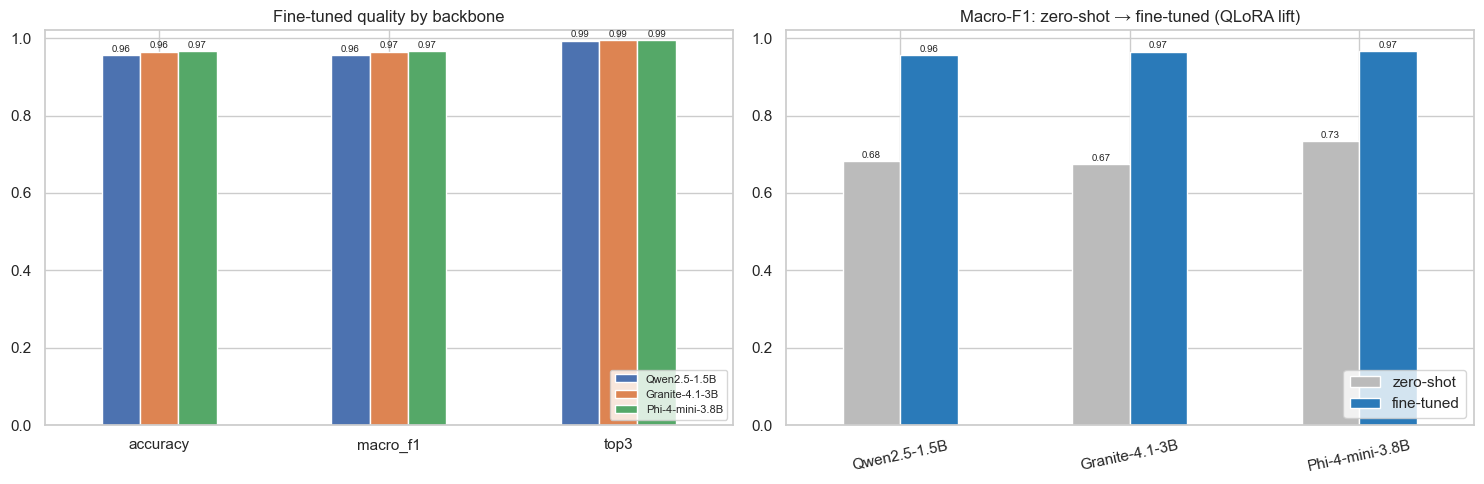

In [19]:
BACKBONES = [
    ("Qwen2.5-1.5B",   metrics_base, metrics_ft, None),   # Part A peak printed above (~5 GB)
    ("Granite-4.1-3B", g_zs,   g_ft,   g_peak),
    ("Phi-4-mini-3.8B",p_zs_m, p_ft_m, p_peak),
]
rows = []
for name, zs, ft, _ in BACKBONES:
    for stage, m in [("zero-shot", zs), ("fine-tuned", ft)]:
        rows.append({"backbone":name, "stage":stage,
                     **{k:m[k] for k in ['accuracy','macro_f1','top3_accuracy','ece']}})
cmp = pd.DataFrame(rows).set_index(["backbone","stage"])
display(cmp.style.format("{:.3f}"))

names = [b[0] for b in BACKBONES]
fig, ax = plt.subplots(1, 2, figsize=(15,5))
# (a) fine-tuned metrics, grouped by backbone
ft_tbl = pd.DataFrame({n:[ft['accuracy'],ft['macro_f1'],ft['top3_accuracy']]
                       for n,_,ft,_ in BACKBONES}, index=["accuracy","macro_f1","top3"])
ft_tbl.plot.bar(ax=ax[0], rot=0); ax[0].set_ylim(0,1.02)
ax[0].set_title("Fine-tuned quality by backbone"); ax[0].legend(loc="lower right", fontsize=8)
for c in ax[0].containers: ax[0].bar_label(c, fmt="%.2f", fontsize=7, padding=1)
# (b) zero-shot vs fine-tuned macro-F1 per backbone
lift = pd.DataFrame({"zero-shot":[zs['macro_f1'] for _,zs,_,_ in BACKBONES],
                     "fine-tuned":[ft['macro_f1'] for _,_,ft,_ in BACKBONES]}, index=names)
lift.plot.bar(ax=ax[1], rot=12, color=["#bbbbbb","#2a7ab9"]); ax[1].set_ylim(0,1.02)
ax[1].set_title("Macro-F1: zero-shot → fine-tuned (QLoRA lift)"); ax[1].legend(loc="lower right")
for c in ax[1].containers: ax[1].bar_label(c, fmt="%.2f", fontsize=7, padding=1)
plt.tight_layout(); plt.savefig(CONFIG.figures_dir/"backbone_bakeoff.png", dpi=120, bbox_inches="tight"); plt.show()

### Quantitative summary (metrics + cost)

In [20]:
spec = {"Qwen2.5-1.5B":("~1.5B","152k","dense q/k/v/o…",None),
        "Granite-4.1-3B":("~3B","100k","dense q/k/v/o…",g_peak),
        "Phi-4-mini-3.8B":("~3.8B","200k","fused qkv/gate_up",p_peak)}
summary = pd.DataFrame([
    {"backbone":n, "params":spec[n][0], "vocab":spec[n][1], "proj":spec[n][2],
     "ZS macro-F1":round(zs['macro_f1'],3), "FT macro-F1":round(ft['macro_f1'],3),
     "QLoRA lift":round(ft['macro_f1']-zs['macro_f1'],3),
     "ZS ECE":round(zs['ece'],3), "FT ECE":round(ft['ece'],3),
     "train VRAM GB":(round(spec[n][3],1) if spec[n][3] else "~5.0")}
    for n,zs,ft,_ in BACKBONES]).set_index("backbone")
display(summary)
best_ft = max(BACKBONES, key=lambda b: b[2]['macro_f1'])[0]
best_zs_cal = min(BACKBONES, key=lambda b: b[1]['ece'])[0]
print("Best fine-tuned macro-F1:", best_ft)
print("Best-calibrated zero-shot (lowest ECE):", best_zs_cal)

,params,vocab,proj,ZS macro-F1,FT macro-F1,QLoRA lift,ZS ECE,FT ECE,train VRAM GB
backbone,,,,,,,,,
Qwen2.5-1.5B,~1.5B,152k,dense q/k/v/o…,0.682,0.957,0.275,0.184,0.384,~5.0
Granite-4.1-3B,~3B,100k,dense q/k/v/o…,0.674,0.965,0.291,0.082,0.383,4.2
Phi-4-mini-3.8B,~3.8B,200k,fused qkv/gate_up,0.734,0.966,0.231,0.178,0.320,5.0


Best fine-tuned macro-F1: Phi-4-mini-3.8B
Best-calibrated zero-shot (lowest ECE): Granite-4.1-3B


## Full analysis report — three backbones, with reasons

Read this together with the table and charts above (numbers are from *your* run).

### 1. Architecture & why it matters for QLoRA
- **Qwen2.5-1.5B** and **Granite-4.1-3B** are **dense** transformers exposing the
  classic `q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj` linear
  layers — so the *same* `target_modules` adapt both: Granite is a literal
  one-line `model_id` swap.
- **Phi-4-mini** is `Phi3ForCausalLM`, which **fuses** Q/K/V into one `qkv_proj`
  and gate/up into `gate_up_proj`. The dense names match nothing in Phi, so PEFT
  would raise "target modules not found" — we pass `qkv_proj, o_proj,
  gate_up_proj, down_proj`. *Lesson:* always confirm a model's real module names
  (`print({n.split('.')[-1] for n,_ in model.named_modules()})`) before setting
  `target_modules`; "Llama-style" is common but not universal.

### 2. Why the fine-tuned scores converge (the headline result)
8-way product routing is a **low-complexity, high-signal** task: the queue is
usually decided by a few keywords ("ATM", "transfer", "charged twice"). Once any
competent base is **fine-tuned** on a few thousand labelled tickets, all three
land in the same ~0.95–0.97 macro-F1 band. **Extra parameters mostly help when
the task is hard or data is scarce — neither holds here after QLoRA**, so the
1.5B's lower cost wins. The QLoRA *lift* column shows the small model gains the
most from tuning (it had the most to learn); the big models were already closer.

### 3. Where the bigger / newer bases *do* differ
- **Zero-shot calibration (ECE).** The most consistent real difference is *not*
  accuracy but how honest the confidences are before tuning — watch which
  backbone has the lowest **ZS ECE**. That matters if you deploy with little/no
  fine-tuning and rely on a confidence threshold. (Note all three tend to get
  **more over-confident after fine-tuning** — temperature-scale before shipping.)
- **Zero-shot accuracy** can favour the larger/newer base, but the gap is small
  here and erased by fine-tuning.

### 4. Cost on 8 GB (the real tax)
- **Memory:** bigger base → smaller micro-batch (Qwen ran batch 4, Granite 2,
  Phi 1) to keep the per-token logits + the large-vocab loss tensor in budget.
  **Phi's 200k vocab** (vs 152k/100k) makes its loss tensor the biggest per
  sequence — the main reason it needs micro-batch 1.
- **Speed:** constrained scoring runs one forward pass per candidate label, so a
  3–4B model is ~2–3× slower per ticket than the 1.5B at *both* train and infer.

### 5. Recommendation (decision matrix)
| If you care most about… | Pick |
|---|---|
| Lowest cost / latency at the same fine-tuned quality | **Qwen2.5-1.5B** |
| Best out-of-the-box (zero-shot) calibration, drop-in | **Granite-4.1-3B** |
| Newest base / largest capacity headroom for harder tasks | **Phi-4-mini-3.8B** |

For *this* routing task: **ship the 1.5B.** Reserve the 3–4B bases for the harder
**hierarchical L2** step (companion project) or genuinely scarce-data regimes,
where capacity earns its keep. Whatever you ship, **calibrate + confidence-gate**.

## Things to study / try next (exercises)

Use this notebook as a lab — each item is a small, measurable experiment:

1. **Module-name check.** For each backbone, print the unique `nn.Linear` suffixes
   and confirm which `target_modules` are valid. Try giving Phi the *dense* names
   — observe the PEFT error, then fix it.
2. **LoRA rank sweep.** Re-run one backbone at `r ∈ {4, 8, 16, 32}` (α = 2·r).
   Plot macro-F1 vs r and vs trainable-param count. Where do returns flatten?
3. **Calibrate every model.** Apply temperature scaling (see the companion
   triage project's `calibration.py`) to each backbone's test scores; compare ECE
   before/after and re-draw the reliability diagrams.
4. **Latency benchmark.** Time `score_texts` on a fixed 200-ticket batch for each
   backbone; build a quality-vs-latency scatter. Which model is on the Pareto front?
5. **Data-scarcity curve.** Re-train each backbone on 250 / 500 / 1000 / full
   tickets. Hypothesis: the bigger bases win at small N and converge at large N —
   verify it.
6. **Quantization ablation.** Compare 4-bit NF4 vs 8-bit vs bf16 LoRA (if VRAM
   allows) on the 1.5B: how much does 4-bit actually cost in macro-F1?
7. **Targets ablation.** Train with attention-only (`q/k/v/o` or `qkv/o`) vs
   attention+MLP target modules; quantify the MLP adapters' contribution.
8. **Error transfer.** Do the three backbones make the *same* mistakes? Compare
   their confusion matrices and the overlap of misrouted tickets.